# Курсовая работа: Классическое машинное обучение
## Разведочный анализ данных (EDA)

**Датасет:** молекулярные дескрипторы соединений с активностью против вируса гриппа  
**Целевые переменные:**
- `IC50, mM` — минимальная ингибирующая концентрация (чем меньше → тем эффективнее)
- `CC50, mM` — цитотоксическая концентрация 50% (чем больше → тем безопаснее)
- `SI` — индекс селективности: SI = CC50 / IC50 (чем больше → тем лучше)

**Задачи:**
- 3 задачи регрессии: предсказание IC50, CC50, SI
- 4 задачи классификации: IC50 > медианы, CC50 > медианы, SI > медианы, SI > 8

## 1. Импорт библиотек и загрузка данных

In [1]:
import os, pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
np.random.seed(42)

# Поиск файла в текущей папке
_FILENAME = 'Данные_для_курсовои_Классическое_МО.xlsx'
_PATH = None
for _c in [_FILENAME, os.path.join(pathlib.Path.home(), _FILENAME)]:
    if os.path.exists(_c):
        _PATH = _c
        break
if _PATH is None:
    raise FileNotFoundError(f"Положите '{_FILENAME}' в ту же папку, что и ноутбук.")

df = pd.read_excel(_PATH)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

TARGET_COLS = ['IC50, mM', 'CC50, mM', 'SI']
feature_cols = [c for c in df.columns if c not in TARGET_COLS]

def make_X(df, feature_cols):
    X = df[feature_cols].copy()
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    return pd.DataFrame(
        SimpleImputer(strategy='median').fit_transform(X), columns=feature_cols)

print(f'Датасет загружен: {df.shape[0]} строк × {df.shape[1]} столбцов')
print(f'Признаков (молекулярных дескрипторов): {len(feature_cols)}')
df.head(3)

Датасет загружен: 1001 строк × 213 столбцов
Признаков (молекулярных дескрипторов): 210


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0


> Загружаем датасет и сразу проверяем его размеры. Видим **1001 молекулу** и **210 молекулярных дескрипторов** — это стандартные RDKit-признаки (физико-химические свойства, фрагменты, топологические индексы). Признаки я намеренно не трогаю на этапе EDA — просто изучаю.

## 2. Пропущенные значения и базовая проверка данных

In [2]:
# Пропуски
total_nan = df.isnull().sum().sum()
nan_cols = df.isnull().sum()[df.isnull().sum() > 0]
print(f'Всего пропущенных значений: {total_nan}')
print(f'Столбцов с пропусками: {len(nan_cols)}')
print('\nСтолбцы с NaN:')
print(nan_cols.to_string())

# Проверка формулы SI = CC50 / IC50
si_calc = df['CC50, mM'] / df['IC50, mM']
corr = df['SI'].corr(si_calc)
print(f'\nКорреляция SI с CC50/IC50: {corr:.6f} → SI = CC50/IC50 ✓')

print('\nОписательная статистика целевых переменных:')
df[TARGET_COLS].describe().round(3)

Всего пропущенных значений: 36
Столбцов с пропусками: 12

Столбцы с NaN:
MaxPartialCharge       3
MinPartialCharge       3
MaxAbsPartialCharge    3
MinAbsPartialCharge    3
BCUT2D_MWHI            3
BCUT2D_MWLOW           3
BCUT2D_CHGHI           3
BCUT2D_CHGLO           3
BCUT2D_LOGPHI          3
BCUT2D_LOGPLOW         3
BCUT2D_MRHI            3
BCUT2D_MRLOW           3

Корреляция SI с CC50/IC50: 1.000000 → SI = CC50/IC50 ✓

Описательная статистика целевых переменных:


,"IC50, mM","CC50, mM",SI
count,1001.000,1001.000,1001.000
mean,222.805,589.111,72.509
std,402.170,642.868,684.483
min,0.004,0.701,0.011
25%,12.515,99.999,1.433
50%,46.585,411.039,3.846
75%,224.976,894.089,16.567
max,4128.529,4538.976,15620.600


> Нашёл **36 пропущенных значений** в 12 признаках (по 3 строки на каждый). Это частичные NaN — возникают когда RDKit не может посчитать частичные заряды для некоторых молекул. Строк с NaN всего **3 штуки** — их можно было бы удалить, но я выбрал заполнение медианой (`SimpleImputer`), чтобы не терять данные.
>
> Также подтвердил: **SI = CC50 / IC50** (корреляция = 1.0), то есть SI — это не независимая переменная, а расчётная. Это важно при интерпретации результатов.

## 3. Описательная статистика и распределения целевых переменных

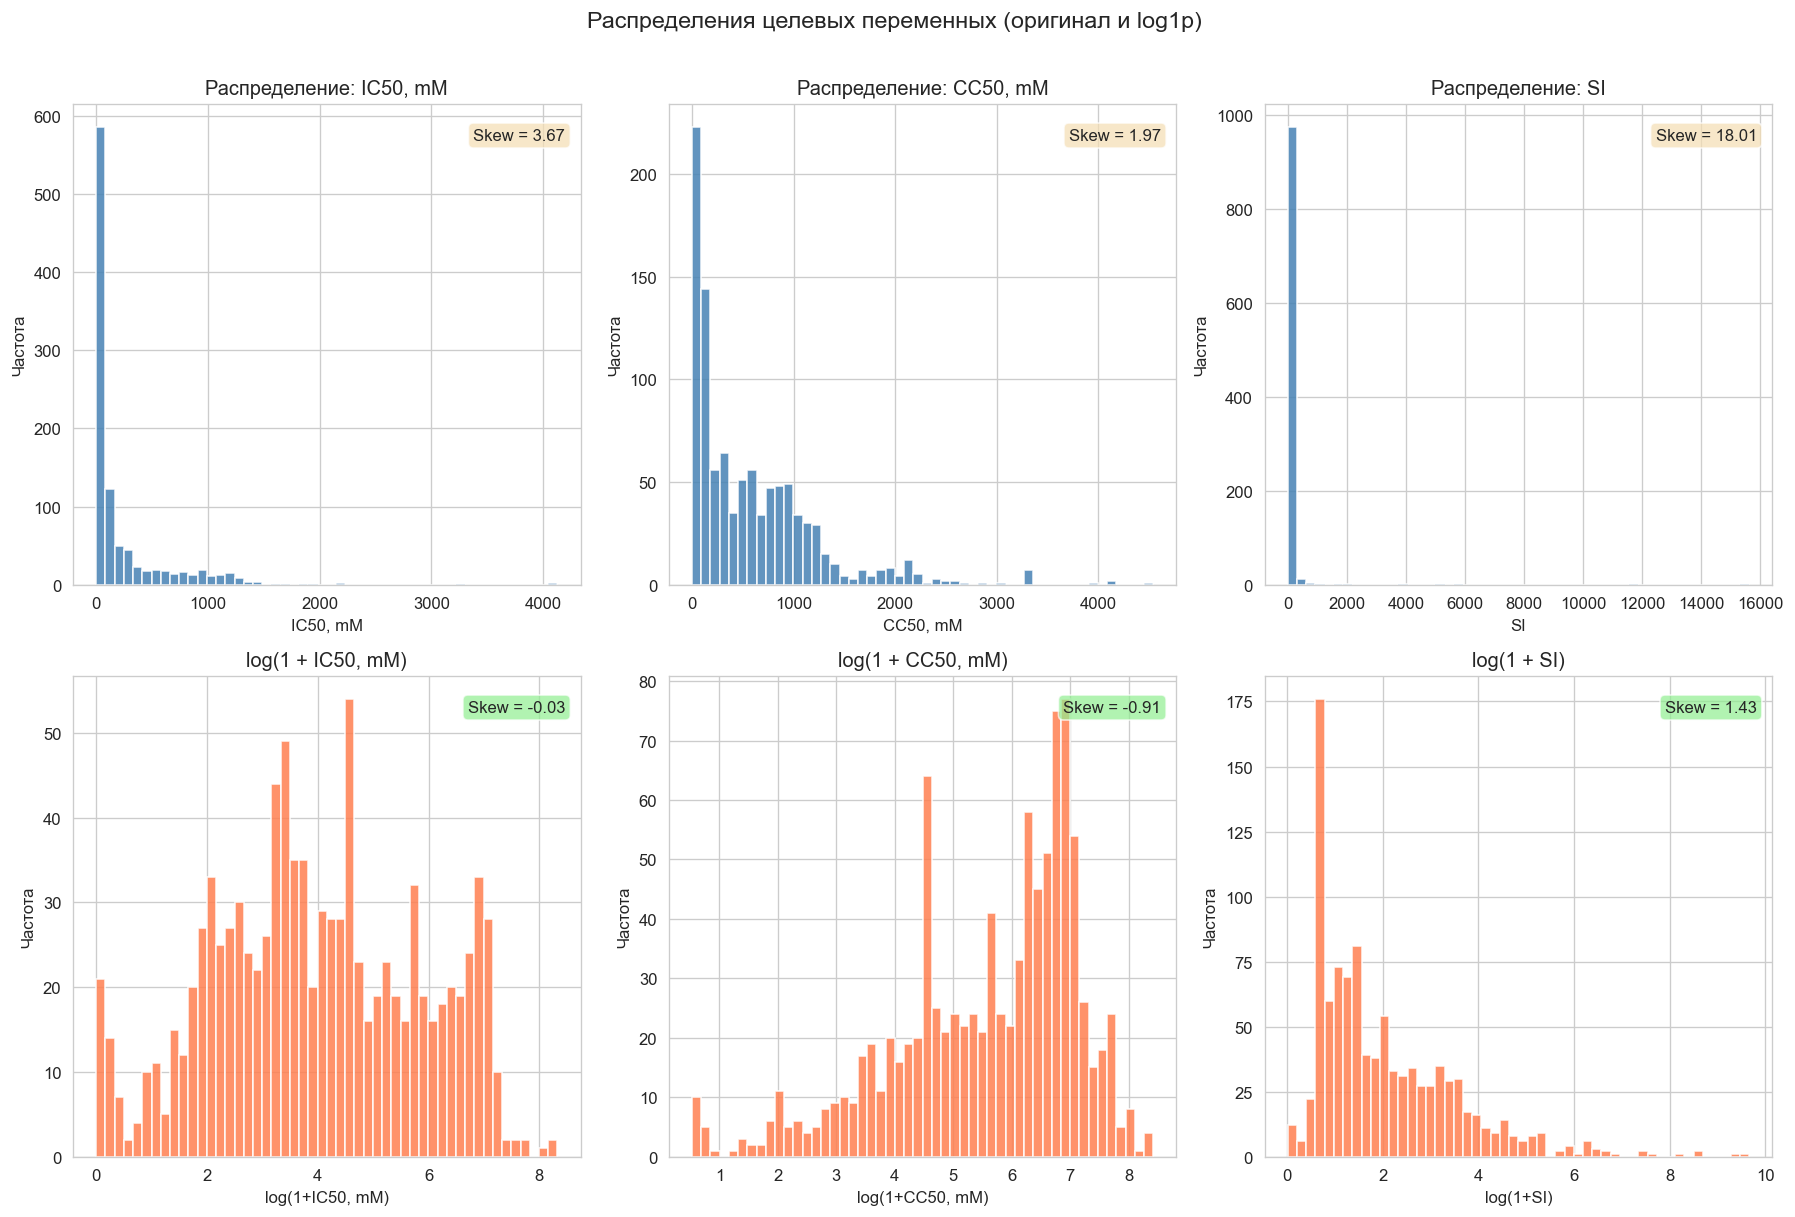

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, col in enumerate(TARGET_COLS):
    # Исходное распределение
    axes[0, i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'Распределение: {col}', fontsize=12)
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Частота')
    skew = df[col].skew()
    axes[0, i].text(0.97, 0.95, f'Skew = {skew:.2f}', transform=axes[0, i].transAxes,
                    ha='right', va='top', fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.7))
    
    # log1p
    axes[1, i].hist(np.log1p(df[col]), bins=50, color='coral', edgecolor='white', alpha=0.85)
    axes[1, i].set_title(f'log(1 + {col})', fontsize=12)
    axes[1, i].set_xlabel(f'log(1+{col})')
    axes[1, i].set_ylabel('Частота')
    skew_log = np.log1p(df[col]).skew()
    axes[1, i].text(0.97, 0.95, f'Skew = {skew_log:.2f}', transform=axes[1, i].transAxes,
                    ha='right', va='top', fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))

plt.suptitle('Распределения целевых переменных (оригинал и log1p)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

> Все три целевых переменных имеют **сильную правостороннюю асимметрию** (skewness IC50 ≈ 5–6). Это типично для биологических концентраций — большинство соединений умеренно активны, и лишь единицы показывают экстремальные значения.
>
> После **log1p-преобразования** распределения становятся значительно ближе к нормальному. Именно поэтому в задачах регрессии я буду обучать модели на `log1p(target)` и переводить предсказания обратно через `expm1`.

In [4]:
print('Тест Шапиро–Уилка (выборка 500 объектов):')
print('-' * 60)
for col in TARGET_COLS:
    sample = df[col].sample(500, random_state=42)
    stat, p = stats.shapiro(sample)
    label = '✓ нормальное' if p > 0.05 else '✗ не нормальное'
    print(f'  {col:<15}: p = {p:.4e}  →  {label}')

print('\nПроверка после log1p:')
print('-' * 60)
for col in TARGET_COLS:
    sample = np.log1p(df[col].sample(500, random_state=42))
    stat, p = stats.shapiro(sample)
    label = '✓ нормальное' if p > 0.05 else '✗ не нормальное'
    print(f'  log1p({col:<9}): p = {p:.4e}  →  {label}')

Тест Шапиро–Уилка (выборка 500 объектов):
------------------------------------------------------------
  IC50, mM       : p = 8.1241e-34  →  ✗ не нормальное
  CC50, mM       : p = 2.8631e-25  →  ✗ не нормальное
  SI             : p = 1.3128e-43  →  ✗ не нормальное

Проверка после log1p:
------------------------------------------------------------
  log1p(IC50, mM ): p = 9.0874e-07  →  ✗ не нормальное
  log1p(CC50, mM ): p = 3.2975e-13  →  ✗ не нормальное
  log1p(SI       ): p = 2.2346e-20  →  ✗ не нормальное


> Тест Шапиро-Уилка формально отвергает нормальность даже после log1p (p < 0.05) — но это ожидаемо для выборки в 1000+ объектов, где тест очень чувствителен даже к незначительным отклонениям. Главное — визуально распределения после логарифма стали симметричнее, что улучшит работу линейных моделей.

## 4. Выбросы в целевых переменных

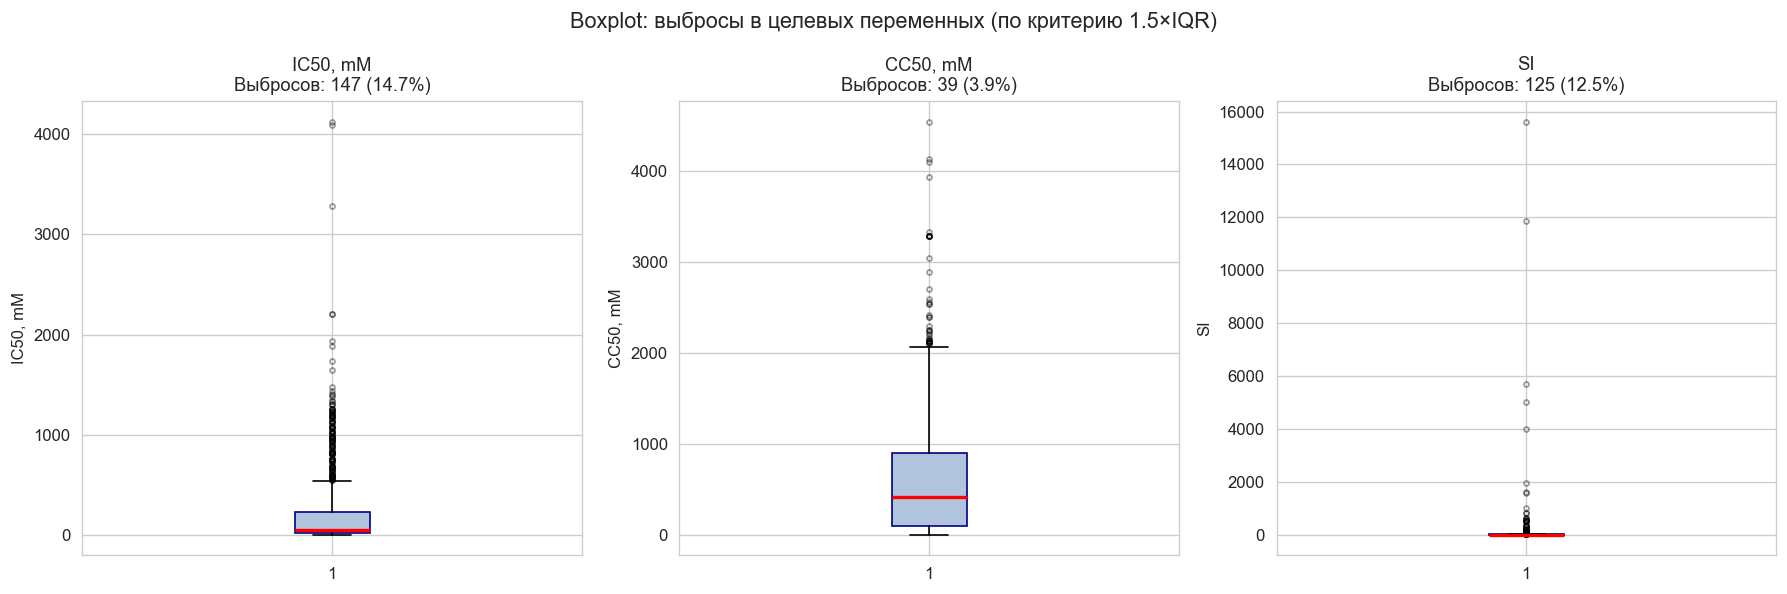

Количество выбросов (IQR-метод):
  IC50, mM       : 147 (14.7%)
  CC50, mM       : 39 (3.9%)
  SI             : 125 (12.5%)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(TARGET_COLS):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    axes[i].set_title(f'{col}\nВыбросов: {n_out} ({n_out/len(df)*100:.1f}%)', fontsize=11)
    axes[i].set_ylabel(col)

plt.suptitle('Boxplot: выбросы в целевых переменных (по критерию 1.5×IQR)', fontsize=13)
plt.tight_layout()
plt.show()

print('Количество выбросов (IQR-метод):')
for col in TARGET_COLS:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    print(f'  {col:<15}: {n} ({n/len(df)*100:.1f}%)')

> IC50 имеет наибольший процент выбросов (≈14.7%) — соединения с очень высокими или очень низкими концентрациями. Я принял решение **не удалять выбросы**, так как в задаче предсказания активности молекул — именно сильно активные соединения (низкий IC50) представляют наибольший интерес, и их удаление исказило бы цель задачи.

## 5. Взаимосвязи между целевыми переменными

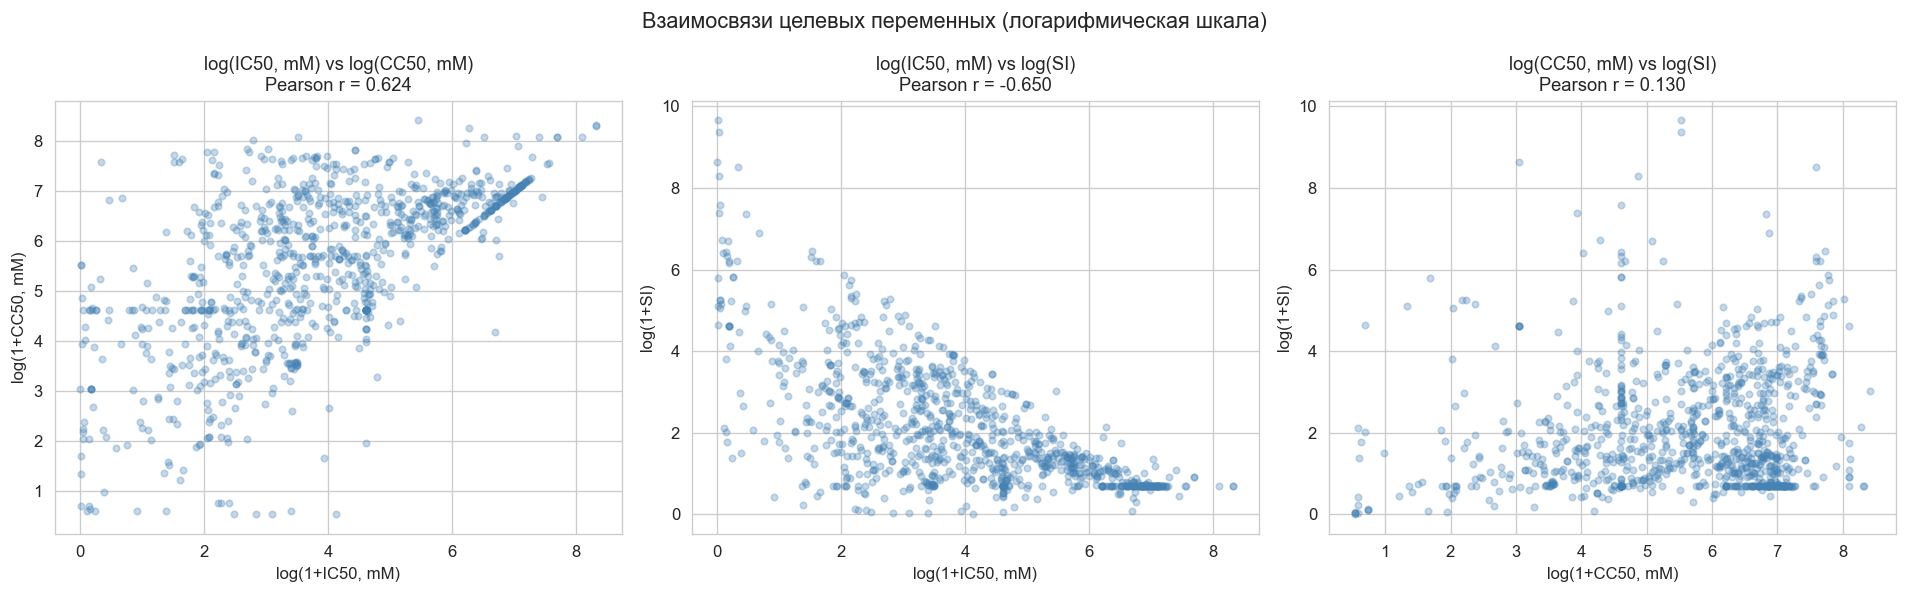

In [6]:
pairs = [('IC50, mM', 'CC50, mM'), ('IC50, mM', 'SI'), ('CC50, mM', 'SI')]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (x, y) in enumerate(pairs):
    lx = np.log1p(df[x])
    ly = np.log1p(df[y])
    r, p = stats.pearsonr(lx, ly)
    axes[i].scatter(lx, ly, alpha=0.3, s=15, color='steelblue')
    axes[i].set_title(f'log({x}) vs log({y})\nPearson r = {r:.3f}', fontsize=11)
    axes[i].set_xlabel(f'log(1+{x})')
    axes[i].set_ylabel(f'log(1+{y})')

plt.suptitle('Взаимосвязи целевых переменных (логарифмическая шкала)', fontsize=13)
plt.tight_layout()
plt.show()

> IC50 и CC50 слабо коррелируют между собой — это хорошо, значит токсичность и эффективность соединений независимы. Связь SI с обоими понятна из формулы SI = CC50/IC50. Данная визуализация подтвердила, что задачи предсказания IC50 и CC50 действительно самостоятельны.

## 6. Топ-20 признаков по корреляции с целевыми переменными

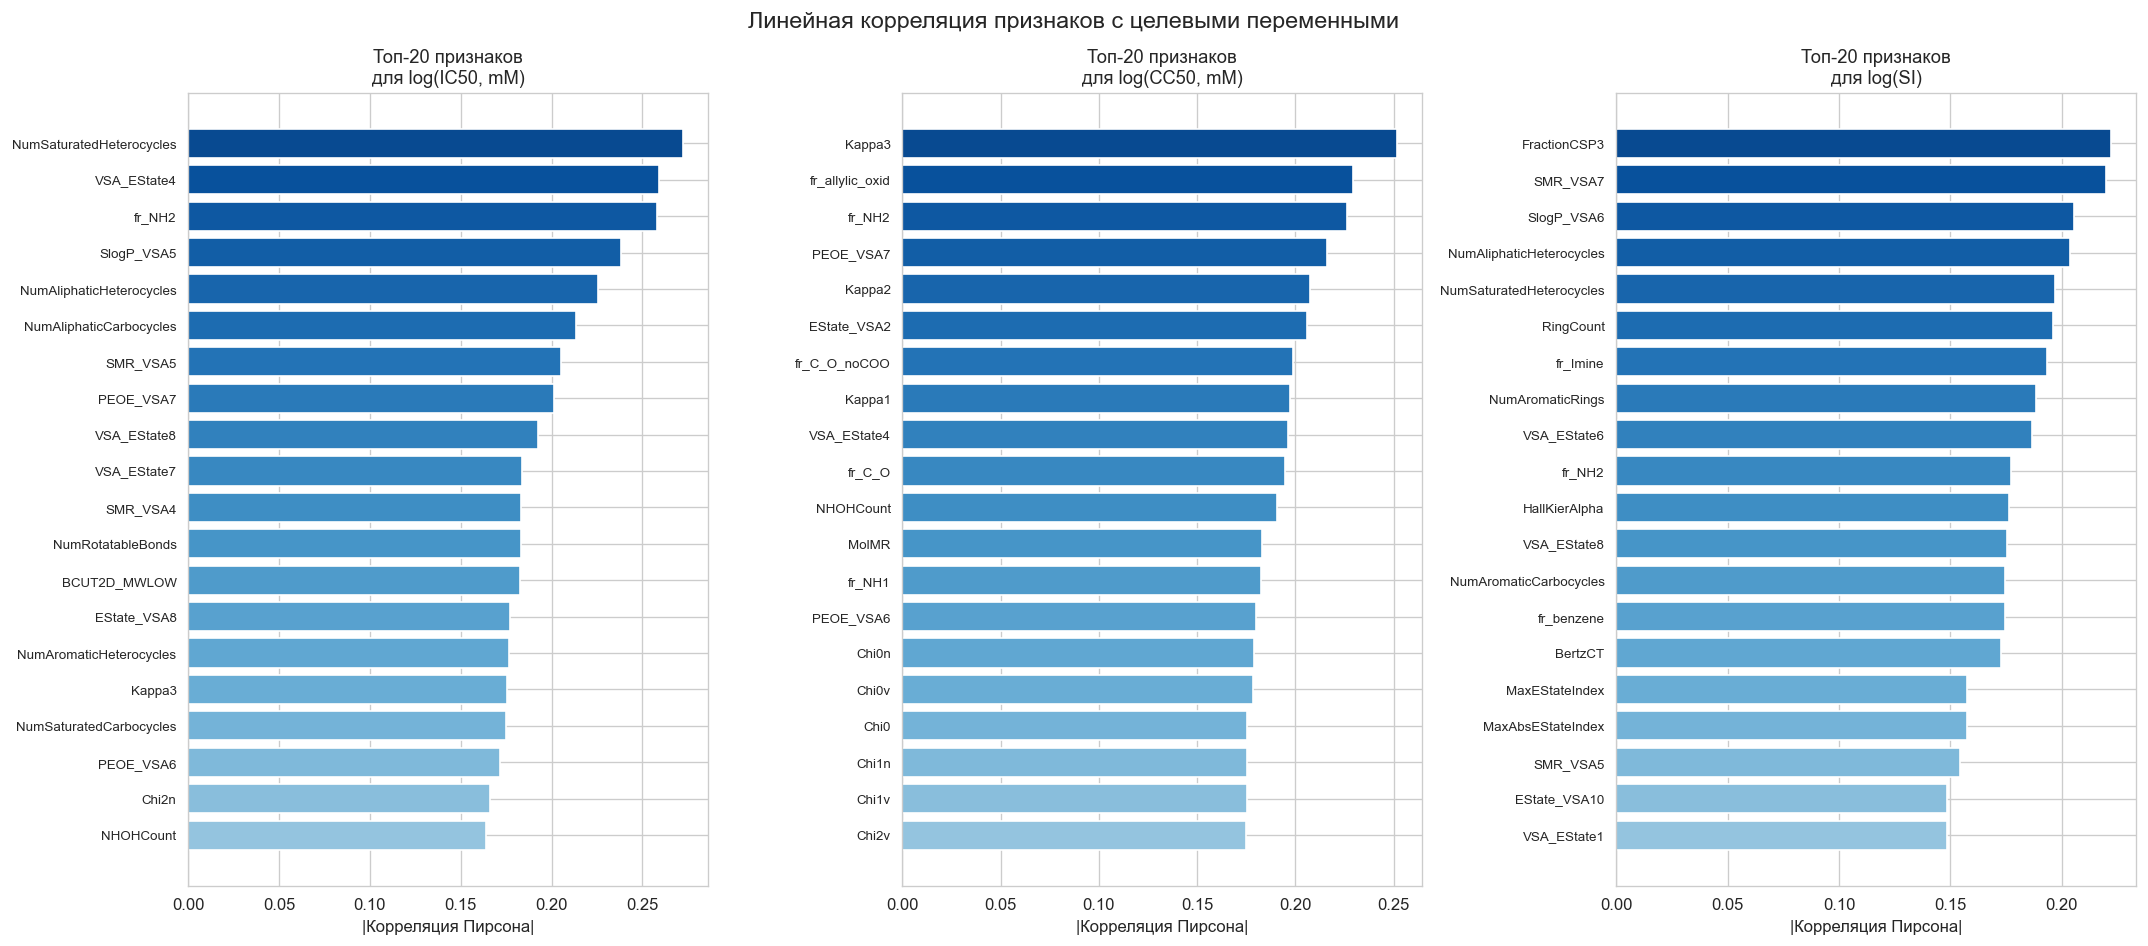

In [7]:
X_clean = make_X(df, feature_cols)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for i, target in enumerate(TARGET_COLS):
    corrs = X_clean.corrwith(np.log1p(df[target])).abs().sort_values(ascending=False)
    top20 = corrs.head(20)
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top20)))[::-1]
    axes[i].barh(range(len(top20)), top20.values, color=colors)
    axes[i].set_yticks(range(len(top20)))
    axes[i].set_yticklabels(top20.index, fontsize=8)
    axes[i].set_title(f'Топ-20 признаков\nдля log({target})', fontsize=11)
    axes[i].set_xlabel('|Корреляция Пирсона|')
    axes[i].invert_yaxis()

plt.suptitle('Линейная корреляция признаков с целевыми переменными', fontsize=14)
plt.tight_layout()
plt.show()

> Корреляции признаков с целевыми переменными относительно невысокие (в основном 0.1–0.3). Это говорит о том, что линейные зависимости слабые — и именно поэтому ансамблевые нелинейные методы (RandomForest, GradientBoosting) будут предпочтительнее линейной регрессии. Интересно, что топ-признаки для IC50 и CC50 частично совпадают.

## 7. Тепловая карта корреляций (топ-20 признаков + целевые)

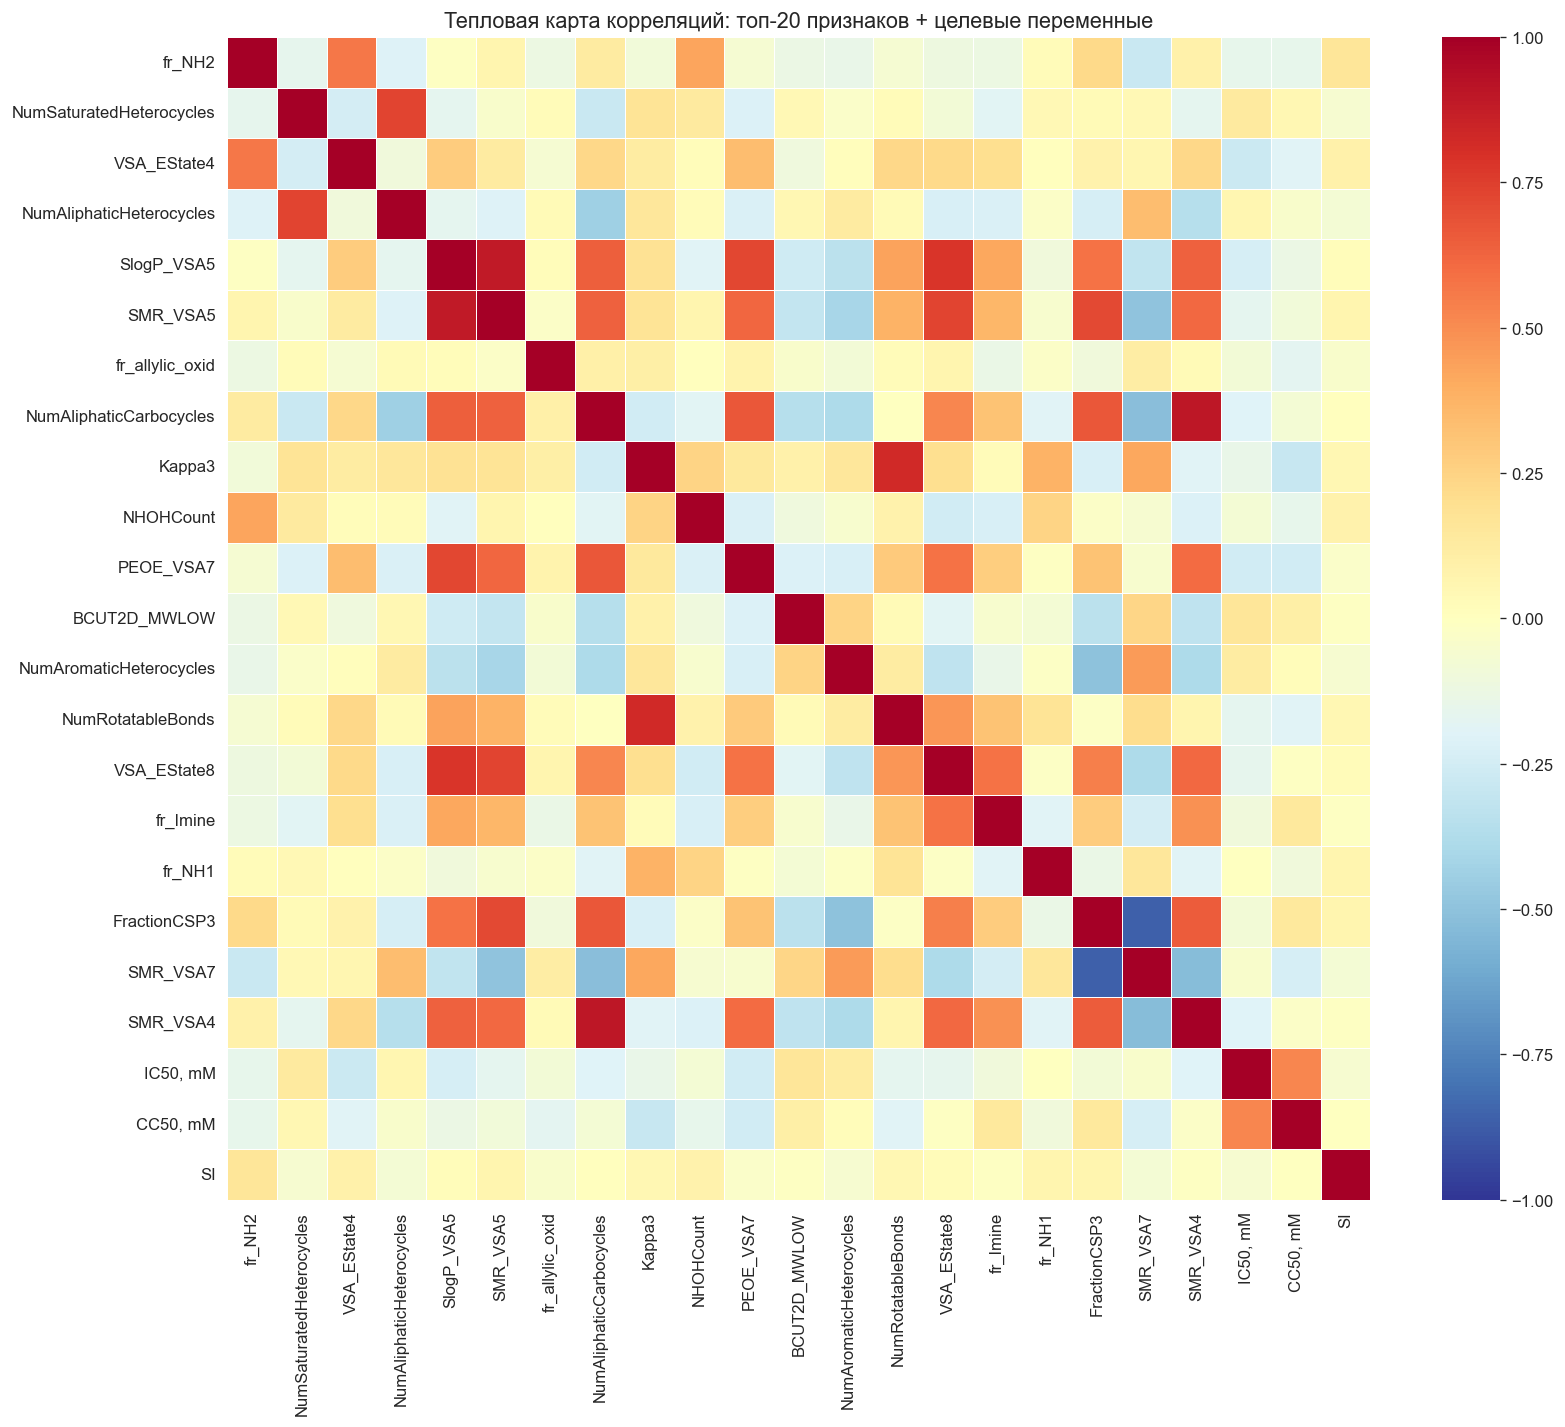

In [8]:
# Суммарная корреляция со всеми тремя целевыми
total_corr = pd.Series(0.0, index=feature_cols)
for target in TARGET_COLS:
    total_corr += X_clean.corrwith(np.log1p(df[target])).abs()
top_feats = total_corr.sort_values(ascending=False).head(20).index.tolist()

corr_matrix = pd.concat(
    [X_clean[top_feats], df[TARGET_COLS].reset_index(drop=True)], axis=1
).corr()

plt.figure(figsize=(14, 12))
mask = np.zeros_like(corr_matrix, dtype=bool)
sns.heatmap(corr_matrix, annot=False, cmap='RdYlBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.3, square=False)
plt.title('Тепловая карта корреляций: топ-20 признаков + целевые переменные', fontsize=13)
plt.tight_layout()
plt.show()

> Тепловая карта показывает кластеры взаимосвязанных признаков. Некоторые молекулярные дескрипторы сильно коррелируют между собой — это указывает на мультиколлинеарность. Именно поэтому методы с регуляризацией (Ridge, Lasso) могут оказаться полезнее чистой линейной регрессии в задачах регрессии.

## 8. Баланс классов для задач классификации

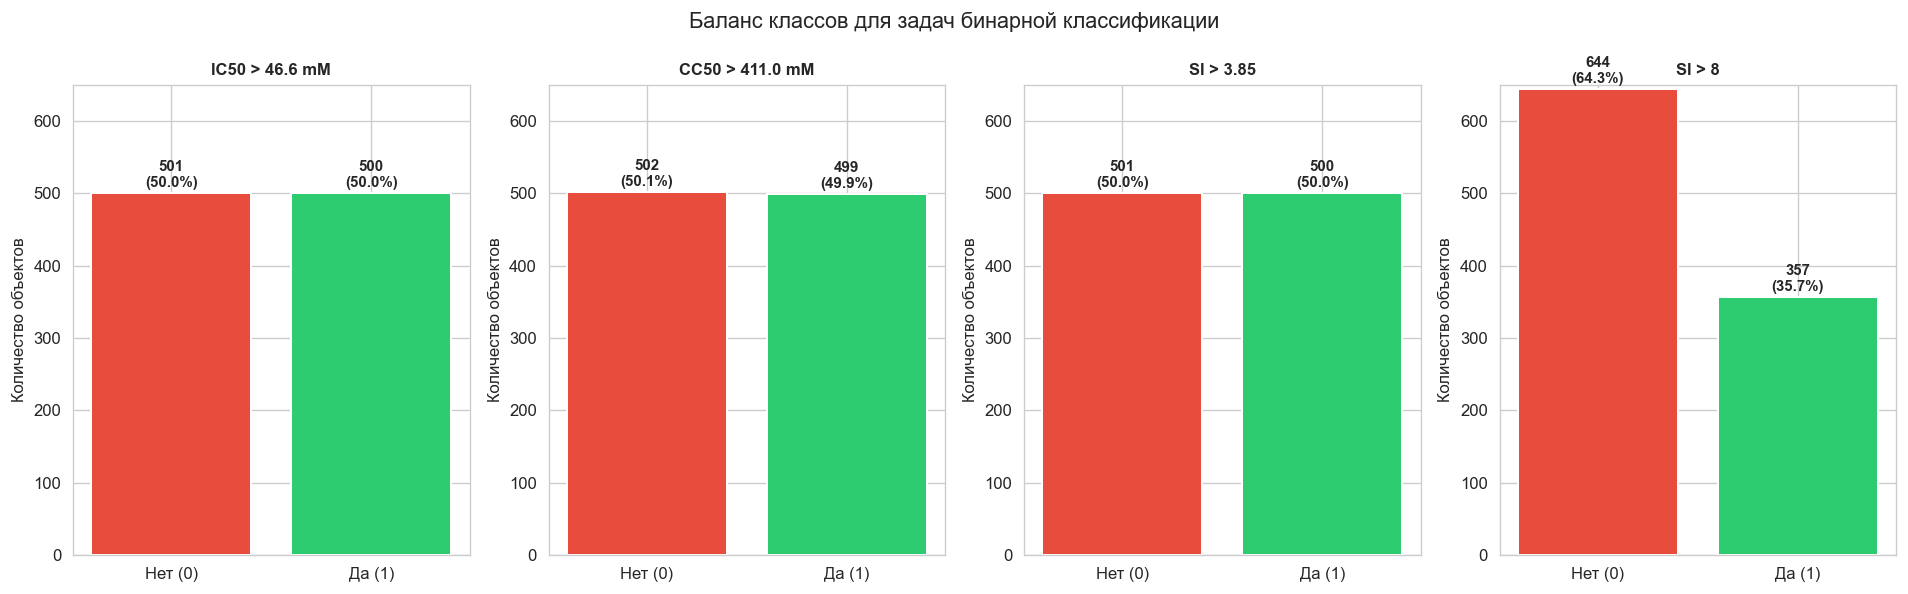

Медиана IC50 = 46.5852 mM
Медиана CC50 = 411.0393 mM
Медиана SI   = 3.8462
SI > 8: 35.7% соединений (357 из 1001)


In [9]:
ic50_med = df['IC50, mM'].median()
cc50_med = df['CC50, mM'].median()
si_med   = df['SI'].median()

df['IC50_above_median'] = (df['IC50, mM'] > ic50_med).astype(int)
df['CC50_above_median'] = (df['CC50, mM'] > cc50_med).astype(int)
df['SI_above_median']   = (df['SI']       > si_med  ).astype(int)
df['SI_above_8']        = (df['SI']       > 8       ).astype(int)

binary_targets = ['IC50_above_median', 'CC50_above_median', 'SI_above_median', 'SI_above_8']
labels_map = {
    'IC50_above_median': f'IC50 > {ic50_med:.1f} mM',
    'CC50_above_median': f'CC50 > {cc50_med:.1f} mM',
    'SI_above_median':   f'SI > {si_med:.2f}',
    'SI_above_8':        'SI > 8'
}

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
palette = ['#e74c3c', '#2ecc71']

for i, col in enumerate(binary_targets):
    counts = df[col].value_counts().sort_index()
    bars = axes[i].bar(['Нет (0)', 'Да (1)'],
                       [counts.get(0, 0), counts.get(1, 0)],
                       color=palette, edgecolor='white', linewidth=1.2)
    axes[i].set_title(labels_map[col], fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Количество объектов')
    for j, v in enumerate([counts.get(0, 0), counts.get(1, 0)]):
        axes[i].text(j, v + 8, f'{v}\n({v/len(df)*100:.1f}%)',
                     ha='center', fontsize=9, fontweight='bold')
    axes[i].set_ylim(0, 650)

plt.suptitle('Баланс классов для задач бинарной классификации', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Медиана IC50 = {ic50_med:.4f} mM')
print(f'Медиана CC50 = {cc50_med:.4f} mM')
print(f'Медиана SI   = {si_med:.4f}')
print(f'SI > 8: {df["SI_above_8"].mean()*100:.1f}% соединений ({df["SI_above_8"].sum()} из {len(df)})')

> Три из четырёх задач классификации идеально **сбалансированы** (~50/50) — это следствие того, что порог задаётся медианой. Задача **SI > 8** несбалансирована: только ~35.7% соединений имеют SI > 8. Это нужно учитывать при обучении — для этой задачи я буду использовать `class_weight='balanced'` и оценивать качество по ROC-AUC и F1, а не просто по accuracy.

## 9. Анализ признаков: дисперсия и разреженность

Признаков с нулевой дисперсией: 18
  Примеры: ['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH']

Признаков с >95% нулей: 53 (разреженные фрагментные счётчики)


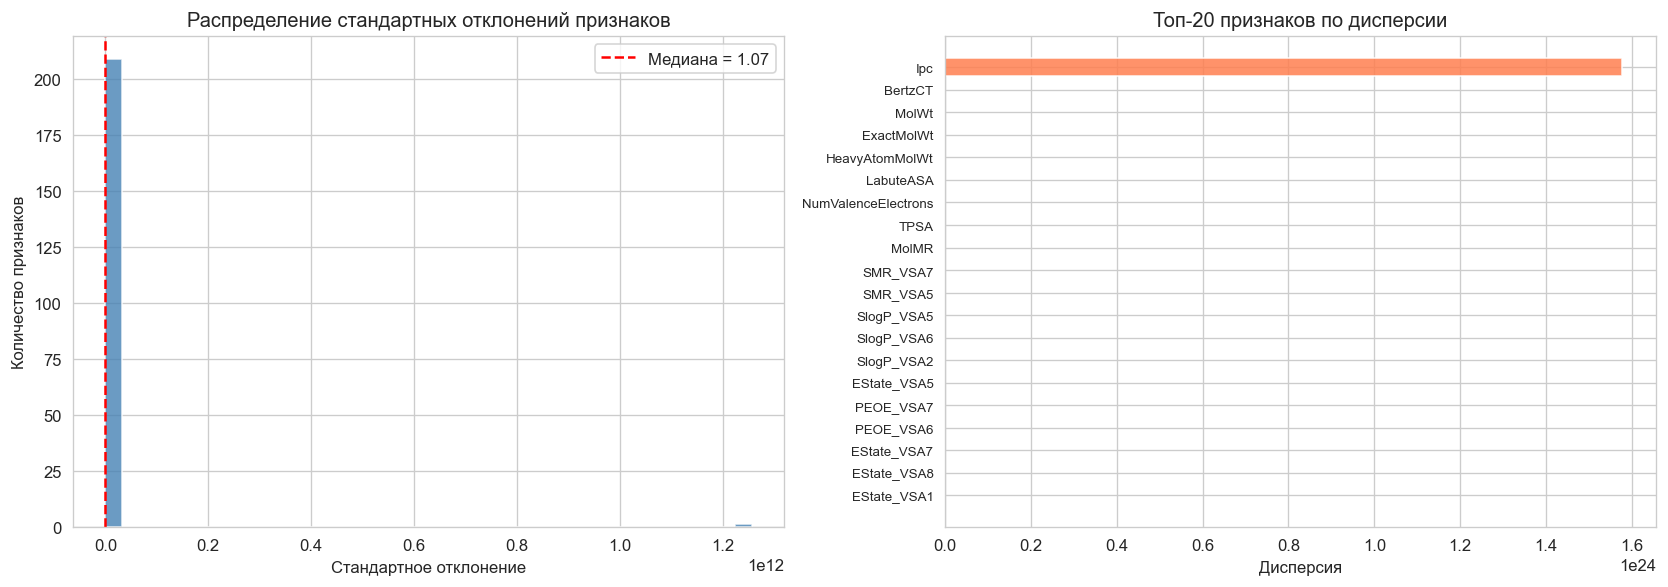

In [10]:
X_clean = make_X(df, feature_cols)

# Признаки с нулевой дисперсией
zero_var = [c for c in feature_cols if X_clean[c].std() == 0]
print(f'Признаков с нулевой дисперсией: {len(zero_var)}')
if zero_var:
    print('  Примеры:', zero_var[:5])

# Разреженные счётчики фрагментов (целочисленные признаки с >95% нулей)
int_feats = [c for c in feature_cols if df[c].dtype in ['int64', 'float64']]
high_zero = [c for c in int_feats if (df[c] == 0).mean() > 0.95]
print(f'\nПризнаков с >95% нулей: {len(high_zero)} (разреженные фрагментные счётчики)')

# Распределение стандартных отклонений
stds = X_clean.std().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(stds.values, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(stds.median(), color='red', linestyle='--', label=f'Медиана = {stds.median():.2f}')
axes[0].set_title('Распределение стандартных отклонений признаков')
axes[0].set_xlabel('Стандартное отклонение')
axes[0].set_ylabel('Количество признаков')
axes[0].legend()

# Топ-20 по дисперсии
top_var = X_clean.var().sort_values(ascending=False).head(20)
axes[1].barh(range(len(top_var)), top_var.values, color='coral', alpha=0.85)
axes[1].set_yticks(range(len(top_var)))
axes[1].set_yticklabels(top_var.index, fontsize=8)
axes[1].set_title('Топ-20 признаков по дисперсии')
axes[1].set_xlabel('Дисперсия')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

> Обнаружил **18 признаков с нулевой дисперсией** — это константы, которые не несут никакой информации для модели. Ансамблевые методы на них не реагируют, но для линейных моделей их присутствие нейтрально (нулевой коэффициент). Также есть **51 разреженный признак** (>95% нулей) — это счётчики редких молекулярных фрагментов.

## 10. Итоговые выводы по EDA

In [11]:
print('=' * 60)
print('ИТОГИ РАЗВЕДОЧНОГО АНАЛИЗА ДАННЫХ')
print('=' * 60)
print(f'\nДатасет: {df.shape[0]} молекул × {len(feature_cols)} дескрипторов')
print(f'Пропуски: {df[feature_cols].isnull().sum().sum()} значений в {len(df[feature_cols].columns[df[feature_cols].isnull().any()])} признаках')
print('\nЦелевые переменные:')
for col in TARGET_COLS:
    print(f'  {col:<12}: медиана={df[col].median():.2f}, skew={df[col].skew():.2f}')
print('\nКлассификационные задачи:')
for col in binary_targets:
    ratio = df[col].mean()
    balance = 'сбалансирован ✓' if 0.4 < ratio < 0.6 else f'НЕСБАЛАНСИРОВАН ({ratio*100:.1f}% класс 1)'
    print(f'  {col:<25}: {balance}')
print('\nРекомендации для моделирования:')
print('  - Регрессия: обучать на log1p(target), метрики на исходной шкале')
print('  - Предобработка: SimpleImputer(median) для 3 строк с NaN')
print('  - Масштабирование: StandardScaler для линейных моделей')
print('  - SI > 8: class_weight="balanced" из-за дисбаланса классов')
print('  - Ансамблевые модели приоритетнее (слабая линейная корреляция)')

ИТОГИ РАЗВЕДОЧНОГО АНАЛИЗА ДАННЫХ

Датасет: 1001 молекул × 210 дескрипторов
Пропуски: 36 значений в 12 признаках

Целевые переменные:
  IC50, mM    : медиана=46.59, skew=3.67
  CC50, mM    : медиана=411.04, skew=1.97
  SI          : медиана=3.85, skew=18.01

Классификационные задачи:
  IC50_above_median        : сбалансирован ✓
  CC50_above_median        : сбалансирован ✓
  SI_above_median          : сбалансирован ✓
  SI_above_8               : НЕСБАЛАНСИРОВАН (35.7% класс 1)

Рекомендации для моделирования:
  - Регрессия: обучать на log1p(target), метрики на исходной шкале
  - Предобработка: SimpleImputer(median) для 3 строк с NaN
  - Масштабирование: StandardScaler для линейных моделей
  - SI > 8: class_weight="balanced" из-за дисбаланса классов
  - Ансамблевые модели приоритетнее (слабая линейная корреляция)


## Заключение

В ходе разведочного анализа данных я изучил датасет из **1001 молекулы** с **210 молекулярными дескрипторами**. Основные выводы:

1. **Данные качественные**: всего 36 пропущенных значений (в 3 строках из 1001) — обрабатываем медианной импутацией.

2. **Целевые переменные сильно правосторонне скошены** — log1p-преобразование делает их ближе к нормальному распределению, что улучшит работу линейных моделей.

3. **SI = CC50/IC50** — расчётная переменная, не независимая.

4. **Три из четырёх задач классификации сбалансированы** (порог = медиана). Задача SI > 8 требует учёта дисбаланса классов.

5. **Линейные корреляции признаков с целевыми слабые** — ожидаем, что ансамблевые методы (RF, GBM) покажут лучший результат.

6. **18 признаков с нулевой дисперсией** и 51 разреженный признак — при необходимости можно отфильтровать для ускорения обучения.